In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd

data = {
    'age': [25, 30, 45, 35, 28, 50, 23, 40],
    'salary': [40000, 60000, 80000, 50000, 45000, 90000, 30000, 70000],
    'years_at_company': [1, 5, 10, 3, 2, 15, 1, 7],
    'overtime': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No'],
    'job_satisfaction': [3, 4, 2, 5, 3, 1, 4, 2],
    'attrition': [1, 0, 1, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

df.head()

,age,salary,years_at_company,overtime,job_satisfaction,attrition
0,25,40000,1,Yes,3,1
1,30,60000,5,No,4,0
2,45,80000,10,Yes,2,1
3,35,50000,3,No,5,0
4,28,45000,2,Yes,3,1


In [ ]:
# Convert categorical data (Yes/No) into numbers (1/0)
df['overtime'] = df['overtime'].map({'Yes': 1, 'No': 0})

# Check dataset
df.head()

,age,salary,years_at_company,overtime,job_satisfaction,attrition
0,25,40000,1,1,3,1
1,30,60000,5,0,4,0
2,45,80000,10,1,2,1
3,35,50000,3,0,5,0
4,28,45000,2,1,3,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               8 non-null      int64
 1   salary            8 non-null      int64
 2   years_at_company  8 non-null      int64
 3   overtime          8 non-null      int64
 4   job_satisfaction  8 non-null      int64
 5   attrition         8 non-null      int64
dtypes: int64(6)
memory usage: 516.0 bytes


In [ ]:
# Features (input)
X = df.drop('attrition', axis=1)

# Target (output)
y = df['attrition']

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create model
model = RandomForestClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Check accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 250  # number of rows

data = {
    'age': np.random.randint(22, 60, n),
    'salary': np.random.randint(30000, 100000, n),
    'years_at_company': np.random.randint(1, 20, n),
    'overtime': np.random.choice([0, 1], n),
    'job_satisfaction': np.random.randint(1, 6, n),
}

df = pd.DataFrame(data)

# Create realistic attrition logic
df['attrition'] = (
    (df['job_satisfaction'] <= 2).astype(int) |
    (df['overtime'] == 1).astype(int) & (df['salary'] < 50000).astype(int)
).astype(int)

df.head()

,age,salary,years_at_company,overtime,job_satisfaction,attrition
0,50,76214,19,1,1,1
1,36,74064,7,1,4,0
2,29,70818,3,1,3,0
3,42,75525,13,0,4,0
4,40,49830,13,1,4,1


In [ ]:
X = df.drop('attrition', axis=1)
y = df['attrition']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [ ]:
df['attrition'] = (
    (df['job_satisfaction'] <= 2).astype(int) |
    (df['overtime'] == 1).astype(int) & (df['salary'] < 50000).astype(int)
).astype(int)

In [ ]:
df['attrition'] = (
    (df['job_satisfaction'] <= 2).astype(int) +
    (df['overtime'] == 1).astype(int) +
    (df['salary'] < 50000).astype(int)
)

# Add randomness
df['attrition'] = df['attrition'].apply(lambda x: 1 if x >= 2 else 0)

# Add noise (real-world effect)
noise = np.random.choice([0, 1], size=n, p=[0.9, 0.1])
df['attrition'] = df['attrition'] ^ noise

In [ ]:
import pandas as pd

# Get feature importance
importance = model.feature_importances_

# Create DataFrame for better view
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

            Feature  Importance
4  job_satisfaction    0.758751
1            salary    0.102877
3          overtime    0.058444
0               age    0.040776
2  years_at_company    0.039152


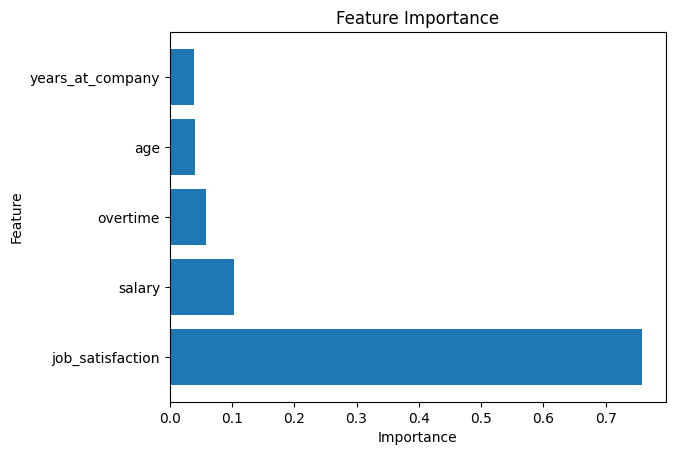

In [ ]:
import matplotlib.pyplot as plt

plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.show()

In [ ]:
resume = """
John Doe
Email: john@example.com
Skills: Python, Machine Learning, Data Analysis, SQL
Experience: 2 years in Data Science
"""

In [ ]:
import re

email = re.findall(r'\S+@\S+', resume)
print("Email:", email)

Email: ['john@example.com']


In [ ]:
skills_list = ['python', 'machine learning', 'data analysis', 'sql']

resume_lower = resume.lower()

found_skills = []

for skill in skills_list:
    if skill in resume_lower:
        found_skills.append(skill)

print("Skills:", found_skills)

Skills: ['python', 'machine learning', 'data analysis', 'sql']


In [ ]:
score = len(found_skills)
print("Candidate Score:", score)

Candidate Score: 4


In [ ]:
resumes = [
    "Python SQL Machine Learning",
    "Java HTML CSS",
    "Python Data Analysis SQL Machine Learning"
]

results = []

for r in resumes:
    r_lower = r.lower()
    score = sum(skill in r_lower for skill in skills_list)
    results.append(score)

print(results)

[3, 0, 4]


In [ ]:
import joblib
joblib.dump(model, "attrition_model.pkl")

['attrition_model.pkl']

In [2]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 84.1 MB/s eta 0:00:00


In [3]:
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("attrition_model.pkl")

st.title("Employee Attrition Predictor")

# Inputs
age = st.number_input("Age", min_value=18, max_value=60)
salary = st.number_input("Salary", min_value=10000, max_value=200000)
years = st.number_input("Years at Company", min_value=0, max_value=40)
overtime = st.selectbox("Overtime", [0, 1])
satisfaction = st.slider("Job Satisfaction", 1, 5)

# Prediction
if st.button("Predict"):
    input_data = pd.DataFrame([[age, salary, years, overtime, satisfaction]],
                              columns=['age', 'salary', 'years_at_company', 'overtime', 'job_satisfaction'])

    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("⚠️ High Risk of Attrition")
    else:
        st.success("✅ Low Risk of Attrition")

2026-04-17 14:50:59.431 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 14:50:59.637 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-17 14:50:59.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 14:50:59.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 14:50:59.641 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 14:50:59.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 14:50:59.646 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 14:50:59.648 Thread 'MainThread': mi

In [4]:
app_code = """
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("attrition_model.pkl")

st.title("Employee Attrition Predictor")

# Inputs
age = st.number_input("Age", min_value=18, max_value=60)
salary = st.number_input("Salary", min_value=10000, max_value=200000)
years = st.number_input("Years at Company", min_value=0, max_value=40)
overtime = st.selectbox("Overtime", [0, 1])
satisfaction = st.slider("Job Satisfaction", 1, 5)

# Prediction
if st.button("Predict"):
    input_data = pd.DataFrame([[age, salary, years, overtime, satisfaction]],
                              columns=['age', 'salary', 'years_at_company', 'overtime', 'job_satisfaction'])

    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("⚠️ High Risk of Attrition")
    else:
        st.success("✅ Low Risk of Attrition")
"""

with open("app.py", "w") as f:
    f.write(app_code)

In [5]:
req_code = """streamlit
pandas
scikit-learn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(req_code)

In [6]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>